In [17]:
from typing import Dict, List, Optional,Literal
from typing import TypedDict,Annotated
from langgraph.graph import StateGraph, END
from langchain_core.messages import AIMessage
from langchain_community.tools import DuckDuckGoSearchResults as DDGS
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
import json
from langchain_core.pydantic_v1 import BaseModel,Field
import os
import dotenv
import re
from datetime import datetime, timedelta

In [18]:
dotenv.load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [33]:
wrapper = DuckDuckGoSearchAPIWrapper(time="w", max_results=15)
search_tool = DDGS(backend="news",api_wrapper=wrapper)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.ddg_search.tool.DuckDuckGoSearchResults'>
duckduckgo_results_json


In [20]:
class Article(TypedDict):
    title: str
    url: str
    date: str
    content: str
    source: str

# Define workflow state
class NewsroomState(TypedDict):
    topic: str
    searched_articles: List[Article]
    reported_articles: List[Article]
    edited_articles: List[Article]
    final_articles: List[Article]
    summary: Optional[str]
    current_stage: Literal["search", "report", "edit", "summarize", "review"]
    error: Optional[str]

In [21]:
def create_initial_state(topic: str) -> NewsroomState:
    """Create initial state for the workflow"""
    return {
        "topic": topic,
        "searched_articles": [],
        "reported_articles": [],
        "edited_articles": [],
        "final_articles": [],
        "summary": None,
        "current_stage": "search",
        "error": None
    }

In [22]:
def extract_json_from_response(content: str) -> List[Article]:
    try:
        # First attempt: direct JSON parsing
        return json.loads(content)
    except json.JSONDecodeError:
        # Second attempt: find JSON array in content
        json_match = re.search(r'\[[\s\S]*\]', content)
        if json_match:
            try:
                return json.loads(json_match.group())
            except json.JSONDecodeError:
                pass
    
    # Final attempt: structured parsing
    articles = []
    current_article = {}
    
    for line in content.split('\n'):
        if '"title":' in line:
            if current_article and all(k in current_article for k in Article.__annotations__):
                articles.append(current_article)
            current_article = {}
        
        for field in Article.__annotations__:
            if f'"{field}":' in line:
                value = line.split(':', 1)[1].strip().strip('",')
                current_article[field] = value
    
    if current_article and all(k in current_article for k in Article.__annotations__):
        articles.append(current_article)
    
    return articles

In [23]:
def update_state(state: NewsroomState, updates: dict) -> NewsroomState:
    new_state = state.copy()
    for key, value in updates.items():
        new_state[key] = value
    return new_state

In [24]:
def search_agent(state: NewsroomState) -> NewsroomState:
    """News Retrieval Search Agent"""
    search_prompt = f"""You are a News Retrieval Search Agent.
    Search for articles related to: {state['topic']}
    
    Requirements:
    - Minimum 10 high-quality articles
    - Filter out: off-topic, low-quality sources, duplicates, opinion pieces
    - Focus on factual reporting
    
    Return ONLY a JSON array of articles in this exact format:
    [
        {{
            "title": "Article Title",
            "url": "https://...",
            "date": "YYYY-MM-DD",
            "content": "Article body...",
            "source": "Source Name"
        }}
    ]"""
    
    try:
        search_results = search_tool.run(f"news {state['topic']}")
        response = model.invoke([HumanMessage(content=f"{search_prompt}\n\nSearch results:\n{search_results}")])
        articles = extract_json_from_response(response.content)
        
        if not articles:
            return update_state(state, {
                "error": "No valid articles found",
                "searched_articles": []
            })
        
        return update_state(state, {
            "searched_articles": articles,
            "current_stage": "report",
            "error": None
        })
    except Exception as e:
        return update_state(state, {
            "error": f"Search failed: {str(e)}",
            "searched_articles": []
        })


In [25]:
def reporter_agent(state: NewsroomState) -> NewsroomState:
    """News Reporter Agent"""
    if not state['searched_articles']:
        return update_state(state, {"error": "No articles to report on"})
    
    reporter_prompt = """You are a skilled News Reporter. Transform this article into an engaging, 
    unbiased story while maintaining accuracy.
    
    Focus on:
    - Clear and concise writing
    - Engaging narrative structure
    - Factual accuracy
    - Balanced perspective
    
    Return ONLY a JSON array with a single article in this exact format:
    [
        {
            "title": "Original title - keep it",
            "url": "Original URL - keep it",
            "date": "Original date - keep it",
            "content": "Your rewritten content here...",
            "source": "Original source - keep it"
        }
    ]"""
    
    try:
        reported_articles = []
        for article in state['searched_articles']:
            response = model.invoke([
                HumanMessage(content=f"{reporter_prompt}\n\nArticle:\n{json.dumps([article], ensure_ascii=False)}")
            ])
            
            processed_articles = extract_json_from_response(response.content)
            if processed_articles:
                reported_articles.extend(processed_articles)
        
        if not reported_articles:
            return update_state(state, {
                "error": "No articles were successfully processed",
                "reported_articles": []
            })
        
        return update_state(state, {
            "reported_articles": reported_articles,
            "current_stage": "edit",
            "error": None
        })
    except Exception as e:
        return update_state(state, {
            "error": f"Reporting failed: {str(e)}",
            "reported_articles": []
        })


In [26]:
def editor_agent(state: NewsroomState) -> NewsroomState:
    """News Editor Agent"""
    if not state['reported_articles']:
        return update_state(state, {"error": "No articles to edit"})
    
    editor_prompt = """You are a meticulous News Editor. Review and refine these articles for:
    - Clarity and readability
    - Logical structure
    - Grammatical accuracy
    - Consistent style
    - Engaging headlines
    
    Return ONLY a JSON array with a single article in this exact format:
    [
        {
            "title": "Original title - keep it",
            "url": "Original URL - keep it",
            "date": "Original date - keep it",
            "content": "Your edited content here...",
            "source": "Original source - keep it"
        }
    ]"""
    
    try:
        edited_articles = []
        for article in state['reported_articles']:
            response = model.invoke([
                HumanMessage(content=f"{editor_prompt}\n\nArticle:\n{json.dumps([article], ensure_ascii=False)}")
            ])
            
            edited_article = extract_json_from_response(response.content)
            if edited_article:
                edited_articles.extend(edited_article)
        
        if not edited_articles:
            return update_state(state, {
                "error": "No articles were successfully edited",
                "edited_articles": []
            })
        
        return update_state(state, {
            "edited_articles": edited_articles,
            "current_stage": "summarize",
            "error": None
        })
    except Exception as e:
        return update_state(state, {
            "error": f"Editing failed: {str(e)}",
            "edited_articles": []
        })

In [ ]:
def summarizer_agent(state: NewsroomState) -> NewsroomState:
    """News Summarizer Agent"""
    if not state['edited_articles']:
        return update_state(state, {"error": "No articles to summarize"})
    
    summarizer_prompt = """You are an expert News Summarizer. Create a comprehensive summary of all the provided articles.
    
    Requirements:
    - Synthesize key information from all articles
    - Identify main themes and trends
    - Include important statistics and data
    - Maintain objectivity
    - Keep summary length to 8-10 sentances
    
    Return ONLY the summary text, no additional formatting."""
    
    try:
        # Combine all articles for context
        combined_articles = "\n\n".join([
            f"Title: {article['title']}\nContent: {article['content']}"
            for article in state['edited_articles']
        ])
        
        response = model.invoke([
            HumanMessage(content=f"{summarizer_prompt}\n\nArticles:\n{combined_articles}")
        ])
        
        summary = response.content.strip()
        
        if not summary:
            return update_state(state, {
                "error": "Failed to generate summary",
                "summary": None
            })
        
        return update_state(state, {
            "summary": summary,
            "current_stage": "review",
            "error": None
        })
    except Exception as e:
        return update_state(state, {
            "error": f"Summarization failed: {str(e)}",
            "summary": None
        })

In [28]:
def newsroom_editor(state: NewsroomState) -> NewsroomState:
    """Newsroom Editor - Final Review"""
    if state.get('error'):
        print("⚠️ Error detected - Redirecting to search stage")
        return update_state(state, {"current_stage": "search"})

    if state.get('current_stage') == "review" and state.get('edited_articles') and state.get('summary'):
        review_prompt = """You are the Chief Newsroom Editor. Review the articles and summary for:
        - Minimum 10 articles requirement
        - Source credibility
        - Content quality and insight
        - Writing style and engagement
        - Summary comprehensiveness and accuracy
        
        You MUST return a JSON object in this exact format:
        {
            "decision": "approve",  # or "reject"
            "reason": "Specific reason for decision",
            "stage": "search"  # or "report" or "edit" or "summarize"
        }"""

        try:
            response = model.invoke([
                HumanMessage(content=f"{review_prompt}\n\nArticles:\n{json.dumps(state['edited_articles'], ensure_ascii=False)}\n\nSummary:\n{state['summary']}")
            ])
            
            # Extract JSON from response
            feedback_match = re.search(r'\{[\s\S]*\}', response.content)
            if feedback_match:
                feedback = json.loads(feedback_match.group())
            else:
                raise json.JSONDecodeError("No valid JSON found", response.content, 0)
            
            print(f"📋 Editor's Decision: {feedback['decision']}")
            print(f"📝 Reason: {feedback['reason']}")
            
            if feedback['decision'] == 'approve':
                print("✅ Articles and summary approved - Workflow complete")
                return update_state(state, {
                    "final_articles": state["edited_articles"],
                    "current_stage": "complete"
                })
            
            print(f"🔄 Content needs revision - Redirecting to {feedback['stage']} stage")
            return update_state(state, {"current_stage": feedback['stage']})
            
        except (json.JSONDecodeError, KeyError) as e:
            print(f"⚠️ Invalid editor response: {str(e)} - Defaulting to edit stage")
            return update_state(state, {"current_stage": "edit"})

    return state

In [30]:
def create_workflow():
    """Create and compile the workflow graph"""
    workflow = StateGraph(NewsroomState)
    
    # Add nodes
    workflow.add_node("search", search_agent)
    workflow.add_node("report", reporter_agent)
    workflow.add_node("edit", editor_agent)
    workflow.add_node("summarize", summarizer_agent)
    workflow.add_node("newsroom_editor", newsroom_editor)
    
    workflow.set_entry_point("newsroom_editor")
    
    # Add conditional edges
    workflow.add_conditional_edges(
        "newsroom_editor",
        lambda x: x["current_stage"],
        {
            "search": "search",
            "report": "report",
            "edit": "edit",
            "summarize": "summarize",
            "complete": END
        }
    )
    
    # Add regular edges
    workflow.add_edge("search", "newsroom_editor")
    workflow.add_edge("report", "newsroom_editor")
    workflow.add_edge("edit", "newsroom_editor")
    workflow.add_edge("summarize", "newsroom_editor")
    
    return workflow.compile()

In [39]:
app = create_workflow()

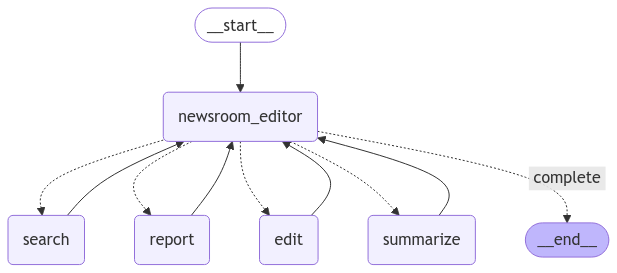

In [40]:
app

In [47]:
if __name__ == "__main__":
    # Initialize model
    model = ChatGroq(
        groq_api_key=GROQ_API_KEY,
        model_name='llama3-8b-8192'
    )
    
    # Test individual nodes
    test_state = create_initial_state("India's got latent")
    response = app.invoke(test_state)
    # test_individual_node(search_agent, test_state)
    # test_individual_node(reporter_agent, test_state)

📋 Editor's Decision: approve
📝 Reason: The articles meet the minimum requirement of 10, and the summary is comprehensive and accurate. The sources are credible, and the content provides valuable insight into the India's Got Latent controversy. The writing style is engaging, and the main themes and trends are clearly identified. However, the objectivity of the summary could be improved by avoiding sensational language and focusing more on the facts.
✅ Articles and summary approved - Workflow complete


In [48]:
response

{'topic': "India's got latent",
 'searched_articles': [{'title': "India's Got Latent Row | Bageshwar Dham Chief Makes SHOCKING Remark On Ranveer Controversy: Maafi Layak Shabd",
   'url': 'https://www.filmibeat.com/bollywood/viral/2025/india-s-got-latent-row-bageshwar-dham-baba-on-ranveer-samay-controversy-maaf-nahi-saaf-kar-dena-c-444125.html',
   'date': '2025-02-16T06:08:00+00:00',
   'content': "As the controversy around Ranveer Allahbadia and Samay Raina's India's Got Latent intensifies, Bageshwar Dham Baba Dhirendra Shastri made a shocking statement in the matter",
   'source': 'FilmiBeat'},
  {'title': "India's Got Latent Row: NCW Summons Ranveer, Samay and Apoorva For the Second Time; Hearing Today | LIVE",
   'url': 'https://www.msn.com/en-in/news/other/india-s-got-latent-row-ncw-summons-ranveer-samay-and-apoorva-for-the-second-time-hearing-today-live/ar-AA1zbs6X',
   'date': '2025-02-17T05:59:08+00:00',
   'content': 'Ranveer Allahbadia faces mass unfollowing, Samay Raina del